# 8.2. 지름 방정식과 양자수

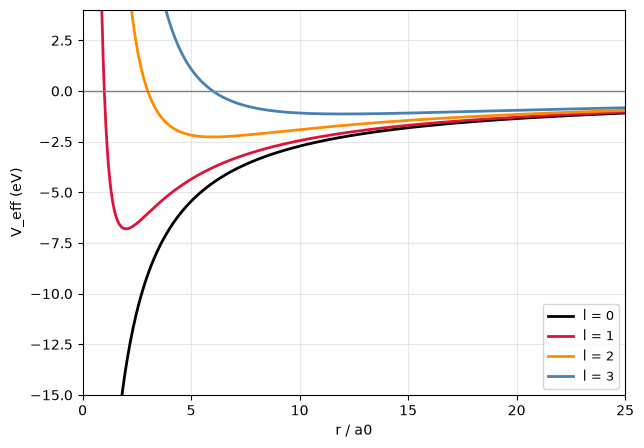

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e, e, epsilon_0

a0 = 5.29177e-11  # Bohr 반지름
k = e**2 / (4 * np.pi * epsilon_0)

r = np.linspace(0.05, 30, 500) * a0

fig, ax = plt.subplots(figsize=(7, 5))
for l, col in zip([0, 1, 2, 3], ["black", "crimson", "darkorange", "steelblue"]):
    V_eff = (-k / r + l * (l + 1) * hbar**2 / (2 * m_e * r**2)) / e
    ax.plot(r / a0, V_eff, lw=2, color=col, label=f"l = {l}")

ax.axhline(0, color="gray", lw=1)
ax.set_xlim(0, 25)
ax.set_ylim(-15, 4)
ax.set_xlabel("r / a0")
ax.set_ylabel("V_eff (eV)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

In [2]:
def solve_1d(V, x, mass, periodic=False):
    N = len(x)
    dx = x[1] - x[0]

    D2 = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    if periodic:
        D2[0, -1] = D2[-1, 0] = 1 / dx**2

    H = -(hbar**2) / (2 * mass) * D2 + np.diag(V)
    E, psi = np.linalg.eigh(H)

    return E, psi / np.sqrt(dx)


N = 2000
r = np.linspace(0, 80 * a0, N + 2)[1:-1]

for l in [0, 1, 2]:
    V_eff = -k / r + l * (l + 1) * hbar**2 / (2 * m_e * r**2)
    E, u = solve_1d(V_eff, r, m_e)

    print(f"l = {l}: {np.round(E[:4] / e, 4)}")

l = 0: [-13.6003  -3.4011  -1.5117  -0.8503]
l = 1: [-3.4015 -1.5118 -0.8504 -0.5441]
l = 2: [-1.5117 -0.8504 -0.5442 -0.3701]


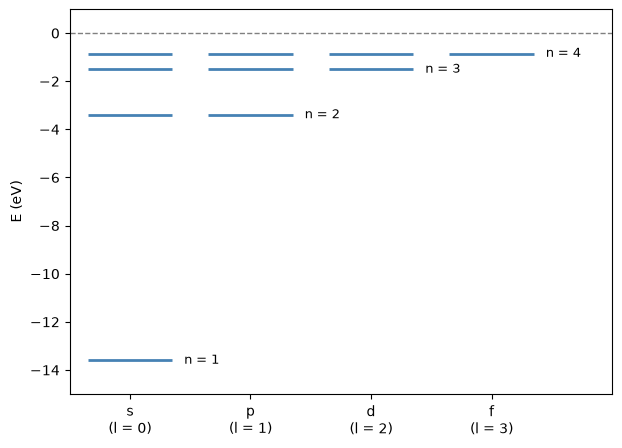

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

for n in range(1, 5):
    E = -13.6057 / n**2
    for l in range(n):
        ax.hlines(E, l - 0.35, l + 0.35, lw=2, color="steelblue")
        if l == n - 1:
            ax.text(l + 0.45, E, f"n = {n}", va="center", fontsize=9)

ax.set_xlim(-0.5, 4)
ax.set_ylim(-15, 1)
ax.set_xticks(range(4))
ax.set_xticklabels(
    ["s\n(l = 0)", "p\n(l = 1)", "d\n(l = 2)", "f\n(l = 3)"]
)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_ylabel("E (eV)")
plt.show()